# LLM Post-Correction of Worst TrOCR Lines (READ Dataset)

## Objective
Use GPT-4o-mini to correct the worst TrOCR predictions on the READ dataset
and compare CER/WER before and after correction.

### Workflow
1. Install dependencies
2. Upload worst_cer_lines.csv
3. Set OpenAI API key
4. Define correction function
5. Filter lines by CER threshold
6. Run LLM correction
7. Compute metrics
8. Plot results
9. Save CSV

### Note
No GPU needed — this notebook only makes API calls.
Free Colab CPU is sufficient.

In [1]:
!pip install -q openai editdistance jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.8 MB/s eta 0:00:00


In [2]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from openai import OpenAI
import editdistance
from jiwer import wer as compute_wer_jiwer

print("All imports successful.")

All imports successful.


In [3]:
from google.colab import files

print("Please upload worst_cer_lines.csv")
uploaded = files.upload()

df_all = pd.read_csv("worst_cer_lines.csv")

print(f"\nLoaded {len(df_all)} lines")
print(f"Columns: {list(df_all.columns)}")
print(f"\nMean TrOCR CER : {df_all['cer'].mean():.4f}")
print(f"Mean TrOCR WER : {df_all['wer'].mean():.4f}")
print("\nSample rows:")
df_all[["rank", "ground_truth", "trocr_pred", "cer"]].head(5)

Please upload worst_cer_lines.csv


Saving worst_cer_lines.csv to worst_cer_lines.csv

Loaded 1040 lines
Columns: ['rank', 'image_filename', 'line_id', 'ground_truth', 'trocr_pred', 'cer', 'wer']

Mean TrOCR CER : 0.0708
Mean TrOCR WER : 0.2951

Sample rows:


,rank,ground_truth,trocr_pred,cer
0,1,Joseff Foresst.,.20 fl Ersgewers etc.,1.00
1,2,:der:,125,1.00
2,3,:ist,13,1.00
3,4,:mit:,ret.,0.80
4,5,amus,man,0.75


In [18]:
# Cell 3b — Upload worst line images
import zipfile
from pathlib import Path

print("Please upload worst_cer_lines.zip")
uploaded_zip = files.upload()

# Unzip
for fname in uploaded_zip:
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall(".")
        print(f"Unzipped {fname}")

images_dir  = Path("./worst_cer_lines")
image_files = sorted(images_dir.glob("*.png"))
print(f"Found {len(image_files)} line images")
print(f"Sample: {image_files[0].name if image_files else 'none'}")

Please upload worst_cer_lines.zip


Saving worst_cer_Images.zip to worst_cer_Images.zip
Unzipped worst_cer_Images.zip
Found 100 line images
Sample: rank001_cer1.000_line_dc996401-fc7f-4d57-9c4d-384a3788608e.png


In [ ]:
os.environ["OPENAI_API_KEY"] = ...
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Quick test to verify key works
try:
    test = client.chat.completions.create(
        model="gpt-4o",
        max_tokens=5,
        messages=[{"role": "user", "content": "Say hi"}]
    )
    print("API key works.")
except Exception as e:
    print(f"API key error: {e}")

API key works.


In [20]:
CER_THRESHOLD = 0.3

SYSTEM_PROMPT = """You are an expert in Early Modern German manuscripts
from 15th to 18th century council records (Ratsprotokolle).
Correct OCR errors while:
- Preserving Early Modern German language and spelling
- Keeping Roman numerals as-is (e.g. xij, xxiiij)
- Preserving period abbreviations (e.g. fl. for Gulden, kr. for Kreuzer)
- Not modernising archaic German words

Return ONLY the corrected text with no explanation."""

# Preview how many lines will be sent to the LLM
above = (df_all["cer"] > CER_THRESHOLD).sum()
print(f"Lines with CER > {CER_THRESHOLD} : {above} / {len(df_all)}")
print(f"  ({above / len(df_all) * 100:.1f}% of lines)")
print(f"  Mean CER of those lines: {df_all[df_all['cer'] > CER_THRESHOLD]['cer'].mean():.4f}")
print(f"\nEstimated cost: < $0.01 at GPT-4o-mini rates")

Lines with CER > 0.3 : 37 / 1040
  (3.6% of lines)
  Mean CER of those lines: 0.4769

Estimated cost: < $0.01 at GPT-4o-mini rates


In [21]:
def compute_cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return compute_wer_jiwer(gt, pred)   # jiwer expects (reference, hypothesis)


def correct_with_llm(trocr_text, retries=3):
    """Send one TrOCR prediction to GPT-4o-mini and return corrected text."""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o",
                max_tokens=256,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": f"OCR output: {trocr_text}\n\nCorrected text:"
                    }
                ]
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt < retries - 1:
                print(f"\n  [ERROR] Retry {attempt+2}/{retries} — {e}")
                time.sleep(5)
            else:
                print(f"  [LLM ERROR] {e}")
                return trocr_text   # fall back to raw prediction if all retries fail


# Quick test on one line
sample_text = df_all.iloc[0]["trocr_pred"]
sample_gt   = df_all.iloc[0]["ground_truth"]
corrected   = correct_with_llm(sample_text)

print("=== Single line test ===")
print(f"Ground truth : {sample_gt}")
print(f"TrOCR output : {sample_text}  (CER {compute_cer(sample_text, sample_gt):.3f})")
print(f"LLM corrected: {corrected}  (CER {compute_cer(corrected, sample_gt):.3f})")

=== Single line test ===
Ground truth : Joseff Foresst.
TrOCR output : .20 fl Ersgewers etc.  (CER 1.000)
LLM corrected: .20 fl. Ersgewerrs etc.  (CER 1.133)


## Cell 7 — Run LLM correction on worst lines

In [22]:
# Cell 7 — Multimodal correction with GPT-4o (image + text)
import base64

IMAGES_DIR = Path("./worst_cer_lines")

def get_image_path(row):
    """Find the image file matching this CSV row by line_id."""
    matches = list(IMAGES_DIR.glob(f"*{row['line_id']}*.png"))
    return matches[0] if matches else None


def correct_with_vision(image_path, trocr_text, retries=3):
    """Send line image + TrOCR prediction to GPT-4o for correction."""
    with open(image_path, "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o",   # vision model
                max_tokens=256,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": (
                                    f"The OCR system produced this text: '{trocr_text}'\n\n"
                                    f"Look at the handwritten line image and correct any OCR errors. "
                                    f"Return ONLY the corrected text with no explanation."
                                )
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/png;base64,{image_data}",
                                    "detail": "high"   # high detail for small text images
                                }
                            }
                        ]
                    }
                ]
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt < retries - 1:
                print(f"\n  [ERROR] Retry {attempt+2}/{retries} — {e}")
                time.sleep(5)
            else:
                print(f"  [LLM ERROR] {e}")
                return trocr_text   # fall back to raw prediction


# Filter lines above CER threshold
worst_df = df_all[df_all["cer"] > CER_THRESHOLD].copy()

print(f"Sending {len(worst_df)} lines to GPT-4o with images...")
print("This takes longer than text-only — ~2-5 seconds per line.\n")

llm_corrections = []
skipped         = 0

for _, row in tqdm(worst_df.iterrows(), total=len(worst_df), desc="Vision correction"):
    image_path = get_image_path(row)

    if image_path is None:
        # No image found — fall back to text-only correction
        llm_corrections.append(row["trocr_pred"])
        skipped += 1
    else:
        llm_corrections.append(correct_with_vision(image_path, row["trocr_pred"]))

    time.sleep(1)   # small delay between calls

worst_df["llm_corrected"] = llm_corrections

if skipped > 0:
    print(f"\nWarning: {skipped} lines had no matching image — kept raw prediction")

# Compute corrected CER and WER
worst_df["corrected_cer"] = worst_df.apply(
    lambda r: compute_cer(r["llm_corrected"], r["ground_truth"]), axis=1
)
worst_df["corrected_wer"] = worst_df.apply(
    lambda r: compute_wer(r["llm_corrected"], r["ground_truth"]), axis=1
)

print(f"\n===== RESULTS =====")
print(f"Mean CER  before correction : {worst_df['cer'].mean():.4f}")
print(f"Mean CER  after  correction : {worst_df['corrected_cer'].mean():.4f}")
print(f"Mean WER  before correction : {worst_df['wer'].mean():.4f}")
print(f"Mean WER  after  correction : {worst_df['corrected_wer'].mean():.4f}")

cer_change = worst_df['cer'].mean() - worst_df['corrected_cer'].mean()
print(f"\nCER {'improved' if cer_change > 0 else 'worsened'} by "
      f"{abs(cer_change):.4f} "
      f"({abs(cer_change) / worst_df['cer'].mean() * 100:.1f}% relative)")

Sending 37 lines to GPT-4o with images...
This takes longer than text-only — ~2-5 seconds per line.



Vision correction: 100%|██████████| 37/37 [01:27<00:00,  2.36s/it]


===== RESULTS =====
Mean CER  before correction : 0.4769
Mean CER  after  correction : 0.7388
Mean WER  before correction : 0.9730
Mean WER  after  correction : 1.0293

CER worsened by 0.2619 (54.9% relative)


## Cell 8 — Preview corrections

In [24]:
print("===== SAMPLE CORRECTIONS =====\n")
for _, row in worst_df.head(10).iterrows():
    print(f"Ground truth : {row['ground_truth']}")
    print(f"TrOCR output : {row['trocr_pred']}  (CER {row['cer']:.3f})")
    print(f"LLM corrected: {row['llm_corrected']}  (CER {row['corrected_cer']:.3f})")
    improved = "✓ improved" if row['corrected_cer'] < row['cer'] else "✗ no improvement"
    print(f"  {improved}")
    print()

===== SAMPLE CORRECTIONS =====

Ground truth : Joseff Foresst.
TrOCR output : .20 fl Ersgewers etc.  (CER 1.000)
LLM corrected: .20 fl Ersgewalt fl.  (CER 1.000)
  ✗ no improvement

Ground truth : :der:
TrOCR output : 125  (CER 1.000)
LLM corrected: Trans.  (CER 1.200)
  ✗ no improvement

Ground truth : :ist
TrOCR output : 13  (CER 1.000)
LLM corrected: Ich  (CER 1.000)
  ✗ no improvement

Ground truth : :mit:
TrOCR output : ret.  (CER 0.800)
LLM corrected: rat.  (CER 0.800)
  ✗ no improvement

Ground truth : amus
TrOCR output : man  (CER 0.750)
LLM corrected: opus  (CER 0.500)
  ✓ improved

Ground truth : Nota
TrOCR output : nom.  (CER 0.750)
LLM corrected: Jesu  (CER 1.000)
  ✗ no improvement

Ground truth : 180
TrOCR output : 128  (CER 0.667)
LLM corrected: 12 Rv  (CER 1.333)
  ✗ no improvement

Ground truth : 183
TrOCR output : 168  (CER 0.667)
LLM corrected: LOV  (CER 1.000)
  ✗ no improvement

Ground truth : ära
TrOCR output : ara.  (CER 0.667)
LLM corrected: ima  (CER 0.667)
  ✗

## Cell 9 — Plot CER and WER before vs after correction

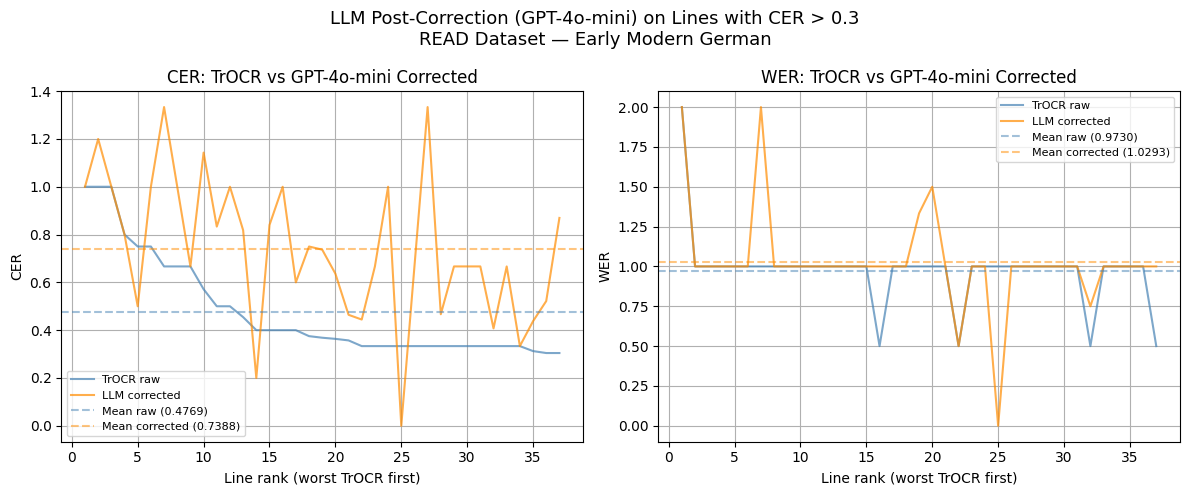

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ranks = worst_df["rank"]

for ax, metric, corrected_col, label in [
    (axes[0], "cer", "corrected_cer", "CER"),
    (axes[1], "wer", "corrected_wer", "WER")
]:
    ax.plot(ranks, worst_df[metric],
            label="TrOCR raw",     color="steelblue",  alpha=0.7)
    ax.plot(ranks, worst_df[corrected_col],
            label="LLM corrected", color="darkorange", alpha=0.7)
    ax.axhline(worst_df[metric].mean(),
               linestyle="--", color="steelblue",  alpha=0.5,
               label=f"Mean raw ({worst_df[metric].mean():.4f})")
    ax.axhline(worst_df[corrected_col].mean(),
               linestyle="--", color="darkorange", alpha=0.5,
               label=f"Mean corrected ({worst_df[corrected_col].mean():.4f})")
    ax.set_xlabel("Line rank (worst TrOCR first)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}: TrOCR vs GPT-4o-mini Corrected")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f"LLM Post-Correction (GPT-4o-mini) on Lines with CER > {CER_THRESHOLD}\n"
    f"READ Dataset — Early Modern German",
    fontsize=13
)
plt.tight_layout()
plt.savefig("llm_correction_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 10 — Save results and download

In [26]:
output_csv = "Multimodal_llm_corrected_results.csv"

cols = [
    "rank", "image_filename", "line_id",
    "ground_truth",
    "trocr_pred",    "cer",           "wer",
    "llm_corrected", "corrected_cer", "corrected_wer"
]

# Only keep columns that exist
cols = [c for c in cols if c in worst_df.columns]
worst_df[cols].to_csv(output_csv, index=False)
print(f"Saved {len(worst_df)} corrected lines to {output_csv}")

# Download both files
from google.colab import files
files.download(output_csv)
files.download("llm_correction_results.png")
print("Downloads started.")

Saved 37 corrected lines to Multimodal_llm_corrected_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.
